# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [100]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [101]:
from google.colab import files
uploaded = files.upload()

Saving patient_demographics.csv to patient_demographics (3).csv
Saving lifestyle_factors.csv to lifestyle_factors (3).csv
Saving clinical_data.csv to clinical_data (3).csv


In [102]:
# Load datasets
demographics = pd.read_csv("/content/patient_demographics.csv")
clinical = pd.read_csv("/content/clinical_data.csv")
lifestyle = pd.read_csv("/content/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [103]:
demographics.head()


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


In [104]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


In [105]:
clinical.describe(include='all')

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,ZWN9666,NaN,101/93,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [106]:
demographics.isnull().sum()

,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [107]:
clinical['Blood Pressure'].head(10)

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88
5,172/86
6,102/73
7,131/68
8,144/105
9,160/70


In [108]:
clinical['Blood Pressure'].dtype

dtype('O')

In [109]:
# clinical['Blood Pressure'].mean()

In [110]:
clinical[['Systolic', 'Diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(int)
clinical

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88
...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,121,94/76,61,1,1,67,19.655895,94,76
8759,QSV6764,120,157/102,73,1,0,617,23.993866,157,102
8760,XKA5925,250,161/75,105,0,1,527,35.406146,161,75
8761,EPE6801,178,119/67,60,1,0,114,27.294020,119,67


In [111]:
clinical['Systolic'].mean()

np.float64(135.07565902088325)

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [112]:
clinical.isna().sum()

,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0
Systolic,0
Diastolic,0


In [113]:
lifestyle.isna().sum()

,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


In [114]:
clinical.head(20)

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88
5,ZOO7941,297,172/86,48,1,1,795,20.146840,172,86
6,WYV0966,358,102/73,84,0,0,284,28.885811,102,73
7,XXM0972,220,131/68,107,0,0,370,22.221862,131,68
8,XCQ5937,145,144/105,68,1,0,790,35.809901,144,105
9,FTJ5456,248,160/70,55,0,1,232,22.558917,160,70


In [115]:
lifestyle.head(20)

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0
5,ZOO7941,1,0,1,0.625008,Unhealthy,2,1
6,WYV0966,1,0,1,4.098177,Healthy,7,1
7,XXM0972,1,1,1,3.427929,Average,4,1
8,XCQ5937,1,1,0,16.868302,Average,5,0
9,FTJ5456,1,1,1,0.194515,Unhealthy,4,0


# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


Skewness: 0.0285


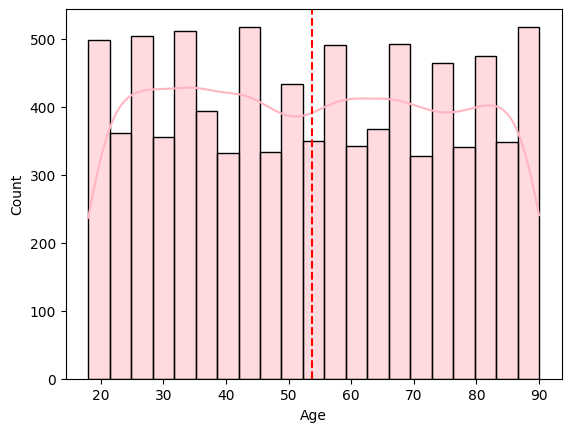

In [116]:
sns.histplot(data=demographics, x='Age', kde=True, color='lightpink')
plt.axvline(demographics['Age'].mean(), color='red', linestyle='--', label='Mean')
print('Skewness:', round(demographics['Age'].skew(), 4))

Skewness: -0.001


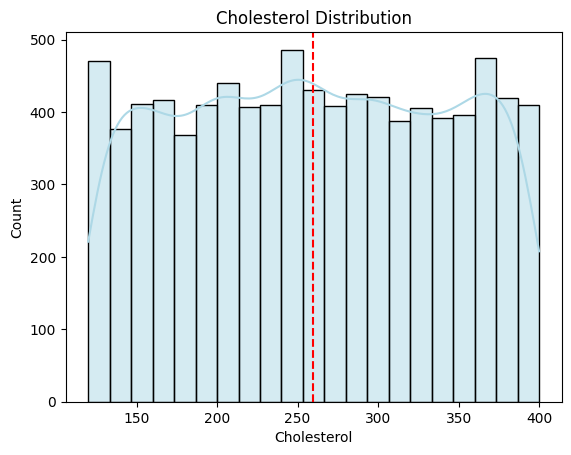

In [117]:
sns.histplot(data=clinical, x='Cholesterol', kde=True, color='lightblue')
plt.axvline(clinical['Cholesterol'].mean(), color='red', linestyle='--', label='Mean')
# plt.axvline(clinical['Cholesterol'].median(), color='green', linestyle='--', label='Median')
plt.title('Cholesterol Distribution')
print('Skewness:', round(clinical['Cholesterol'].skew(), 4))

Skewness: 0.036


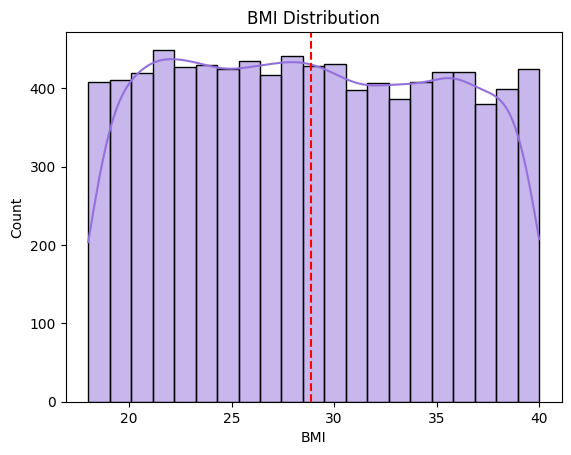

In [118]:
sns.histplot(data=clinical, x='BMI', kde=True, color='mediumpurple')
plt.axvline(clinical['BMI'].mean(), color='red', linestyle='--', label='Mean')
plt.title('BMI Distribution')
print('Skewness:', round(clinical['BMI'].skew(), 4))

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

<Axes: xlabel='Smoking', ylabel='count'>

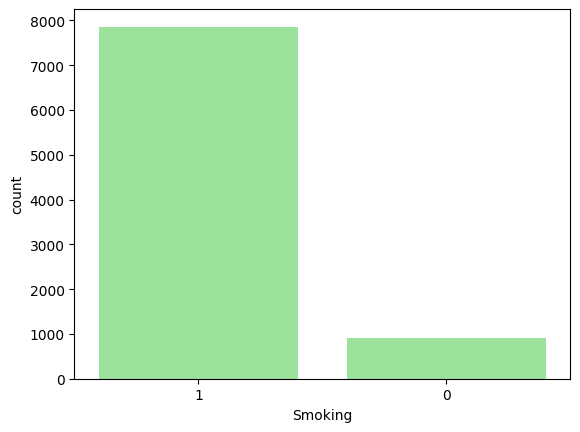

In [119]:
sns.countplot(data=lifestyle, x='Smoking',
              order=lifestyle['Smoking'].value_counts().index, color='lightgreen')

<Axes: xlabel='Diet', ylabel='count'>

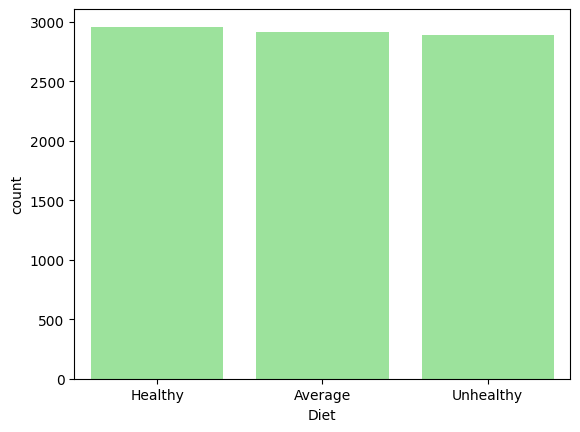

In [120]:
sns.countplot(data=lifestyle, x='Diet',
              order=lifestyle['Diet'].value_counts().index, color='lightgreen')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Germany'),
  Text(1, 0, 'Argentina'),
  Text(2, 0, 'Brazil'),
  Text(3, 0, 'United Kingdom'),
  Text(4, 0, 'Australia'),
  Text(5, 0, 'Nigeria'),
  Text(6, 0, 'France'),
  Text(7, 0, 'Canada'),
  Text(8, 0, 'China'),
  Text(9, 0, 'New Zealand')])

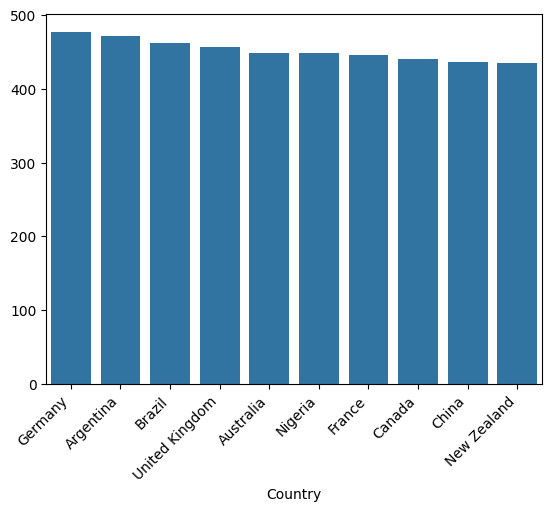

In [121]:
top10 = demographics['Country'].value_counts().head(10)
axes = sns.barplot(x=top10.index, y=top10.values)
plt.xticks(rotation=45, ha='right')

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

,Heart Attack Risk
Smoking,
0,0.363938
1,0.357552


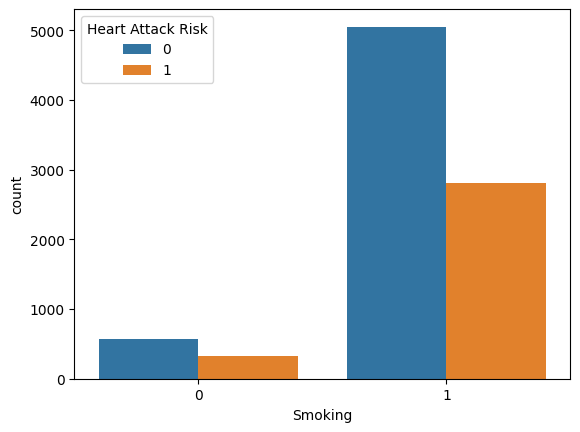

In [122]:
sns.countplot(data=lifestyle, x='Smoking', hue='Heart Attack Risk')
lifestyle.groupby('Smoking')['Heart Attack Risk'].mean()

,Heart Attack Risk
Diet,
Average,0.352335
Healthy,0.364527
Unhealthy,0.357662


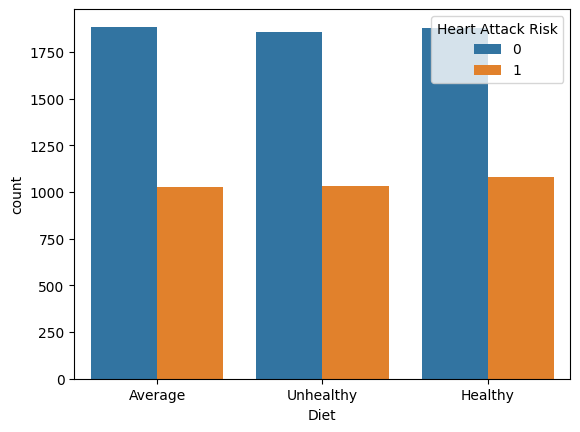

In [123]:
sns.countplot(data=lifestyle, x='Diet', hue='Heart Attack Risk')
lifestyle.groupby('Diet')['Heart Attack Risk'].mean()

,Heart Attack Risk
Smoking,
0,0.363938
1,0.357552


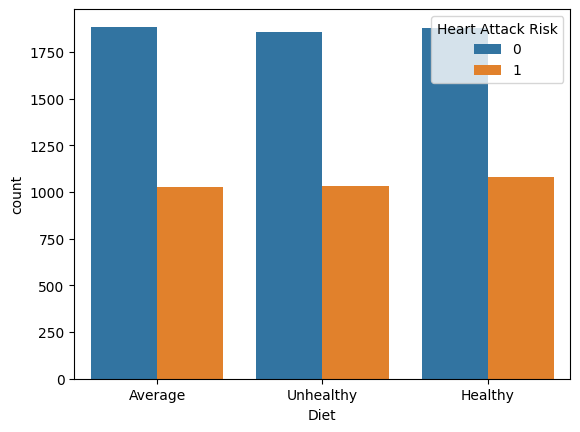

In [124]:
mergedTable = lifestyle.merge(demographics[['Patient ID', 'Sex']], on='Patient ID')
sns.countplot(data=mergedTable, x='Diet', hue='Heart Attack Risk')
mergedTable.groupby('Smoking')['Heart Attack Risk'].mean()

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [125]:
# Your code here

In [126]:
# Your code here

In [127]:
# Your code here

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

In [128]:
# Your code here

In [129]:
# Your code here

In [130]:
# Your code here

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [131]:
# Your code here

In [132]:
# Your code here

In [133]:
# Your code here

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here: